# Part (1)(a) Burgers' Equation Solver

Below is a Burgers' equation solver following the methodology shown in **Unit 13**. The code uses:

1. **A Newton Solver for Nonlinear Systems (`myNewtonSys`):**  
   - Adapted from Unit 13, this function solves nonlinear systems of equations iteratively.

2. **A Finite-Difference Jacobian Approximation (`fdJacobian`):**  
   - Adapted from Unit 13, this function computes a numerical approximation of the Jacobian matrix using finite differences.

3. **A Function `fun_burgers`:**  
   - Forms the nonlinear residual equations for the implicit Euler step of the Burgers' equation:  

4. **Driver Routine `burgersModel`:**   
     - Sets up the spatial grid and initial conditions.  
     - Advances the solution forward in time using the implicit Euler method.  
     - At each time step, solves the nonlinear system using Newton's method.

---

In [30]:
import numpy as np
from numpy.linalg import norm
import copy
from matplotlib import pyplot as plt
%matplotlib inline

In [31]:
def myNewtonSys(fnon, jac, x0, tol, maxk, *fnonargs):
    """
    Newton solver for systems of nonlinear equations.
    fnon      - name of the nonlinear function f(x)
    jac       - name of the Jacobian function
    x0        - initial guess for solution (1D array)
    tol       - stopping tolerance
    maxk      - maximum number of Newton iterations
    fnonargs  - additional arguments passed to fnon and jac
    """
    
    k = 0
    x = x0.copy()

    F = eval(fnon)(x,*fnonargs)
    n = F.size

    while (norm(F,2) > tol and k < maxk):
        J = eval(jac)(x,n,fnon,F,*fnonargs)

        delta = np.linalg.solve(J,-F)
        x = x + delta

        F = eval(fnon)(x,*fnonargs)
        k += 1

    if (k >= maxk):
        print('Not converged')
    return x, k

In [32]:
def fdJacobian(x,n,fnon,F0,*fnonargs):
    """
    Finite difference approximation of Jacobian.
    """
    
    J = np.zeros((n,n), dtype=np.float64)
    h = 1e-8

    for col in range(n):
        xb = x.copy()
        xb[col] += h
        F = eval(fnon)(xb,*fnonargs)

        for i in range(n):
            J[i,col] = (F[i] - F0[i]) / h
    return J

In [33]:
def fun_burgers(uk, ukp, dt, h, nu, ua, ub):
    """
    Compute the residual vector F for the discretized Burgers' equation using an implicit scheme.

    Inputs:
        uk   - current time step solution vector (U^k) of size m (1D array)
        ukp  - previous time step solution vector (U^{k-1}) of size m (1D array)
        dt   - time step size Δt
        h    - spatial grid size h
        nu   - kinematic viscosity ν
        ua   - boundary condition at x=a
        ub   - boundary condition at x=b

    Output:
        F - residual vector of size m (1D array)
    """
    
    m = uk.size
    F = np.zeros(m)

    # Boundary conditions
    F[0] = uk[0] - ua
    F[m-1] = uk[m-1] - ub

    # Internal nodes
    for i in range(1, m-1):
        term_time = (uk[i] - ukp[i]) / dt
        term_conv = uk[i] * ((uk[i] - uk[i-1]) / h)
        term_diff = nu * (uk[i+1] - 2*uk[i] + uk[i-1]) / (h**2)
        F[i] = term_time + term_conv - term_diff

    return F

In [34]:
def initialData_step(m):
    """
    Example initial condition for Burgers equation.
    """
    
    # Create a step function at x=0.1
    x = np.linspace(0,1,m)
    u0 = np.zeros(m)
    u0[x <= 0.1] = 1.0
    # Values greater than 0.1 remain 0.0
    return u0


In [35]:
def burgersModel(dt, nTimeSteps, m, nu, ua, ub):
    h = 1.0/(m-1)

    # Initial condition (step at x=0.1)
    uOld = initialData_step(m)
    u0 = uOld.copy()

    sols = []
    sols.append(uOld.copy())

    total_newton_iterations = 0

    for k in range(nTimeSteps):
        # Solve nonlinear system using Newton
        u, newton_iters = myNewtonSys("fun_burgers", "fdJacobian", uOld.copy(), 1e-8, 50, uOld, dt, h, nu, ua, ub)

        # Update
        uOld = u.copy()
        sols.append(uOld.copy())
        total_newton_iterations += newton_iters

    x = np.linspace(0,1,m)
    return sols, x, total_newton_iterations


# Part (1)(b): Derivation of the Jacobian Elements

#### Here is the Discrete Equation $(2)$ for $i = 2, 3, \dots, m-1$:

## $F_i(U) = \frac{U_i^k - U_i^{k-1}}{\Delta t} + \frac{U_i^k U_i^k - U_{i-1}^k}{h} - \nu \frac{U_{i+1}^k - 2U_i^k + U_{i-1}^k}{h^2} = 0$

### Computation of derivatives as follows:  
## $\frac{\partial F_i}{\partial U_{i-1}^k}$, $\frac{\partial F_i}{\partial U_i^k}$, $\frac{\partial F_i}{\partial U_{i+1}^k}$.

---

## Derivative of $U_{i-1}^k$:

### 1. **Time Term:**  
###   The term $\frac{U_i^k - U_i^{k-1}}{\Delta t}$ does not depend on $U_{i-1}^k$.

### 2. **Convective Term:**  
###   $\frac{U_i^k U_i^k - U_{i-1}^k}{h} = \frac{U_i^{k^2} - U_i^k U_{i-1}^k}{h}$  
###   Differentiating w.r.t. $U_{i-1}^k$:  
###   $\frac{\partial}{\partial U_{i-1}^k} \left( \frac{U_i^k U_i^k - U_{i-1}^k}{h} \right) = -\frac{U_i^k}{h}$

### 3. **Diffusion Term:**  
###   $-\nu \frac{U_{i+1}^k - 2U_i^k + U_{i-1}^k}{h^2}$  
###   Differentiating w.r.t. $U_{i-1}^k$:  
###   $\frac{\partial}{\partial U_{i-1}^k} \left( -\nu \frac{U_{i+1}^k - 2U_i^k + U_{i-1}^k}{h^2} \right) = -\frac{\nu}{h^2}$

### 4. **Summing Contributions:**  
##   $\frac{\partial F_i}{\partial U_{i-1}^k} = -\frac{U_i^k}{h} - \frac{\nu}{h^2}$

---

## Derivative of $U_i^k$:

### 1. **Time Term:**  
###   $\frac{\partial}{\partial U_i^k} \left( \frac{U_i^k - U_i^{k-1}}{\Delta t} \right) = \frac{1}{\Delta t}$

### 2. **Convective Term:**  
###   $\frac{U_i^k U_i^k - U_{i-1}^k}{h} = \frac{U_i^{k^2} - U_i^k U_{i-1}^k}{h}$  
###   Differentiating w.r.t. $U_i^k$:  
###   $\frac{\partial}{\partial U_i^k} \left( \frac{U_i^{k^2} - U_i^k U_{i-1}^k}{h} \right) = \frac{2U_i^k - U_{i-1}^k}{h}$

### 3. **Diffusion Term:**  
###   $-\nu \frac{U_{i+1}^k - 2U_i^k + U_{i-1}^k}{h^2}$  
###   Differentiating w.r.t. $U_i^k$:  
###   $\frac{\partial}{\partial U_i^k} \left( -\nu \frac{U_{i+1}^k - 2U_i^k + U_{i-1}^k}{h^2} \right) = \frac{2\nu}{h^2}$

### 4. **Summing Contributions:**  
##   $\frac{\partial F_i}{\partial U_i^k} = \frac{1}{\Delta t} + \frac{2U_i^k - U_{i-1}^k}{h} - \frac{2\nu}{h^2}$

---

## Derivative of $U_{i+1}^k$:

### 1. **Time and Convective Terms:**  
###   These terms do not depend on $U_{i+1}^k$.

### 2. **Diffusion Term:**  
###   $-\nu \frac{U_{i+1}^k - 2U_i^k + U_{i-1}^k}{h^2}$  
###   Differentiating w.r.t. $U_{i+1}^k$:  
###   $\frac{\partial}{\partial U_{i+1}^k} \left( -\nu \frac{U_{i+1}^k - 2U_i^k + U_{i-1}^k}{h^2} \right) = -\frac{\nu}{h^2}$

### 3. **Summing Contributions:**  
##   $\frac{\partial F_i}{\partial U_{i+1}^k} = -\frac{\nu}{h^2}$

---

## Final Results of (1)(b):

## $\frac{\partial F_i}{\partial U_{i-1}^k} = -\frac{U_i^k}{h} - \frac{\nu}{h^2}$  
## $\frac{\partial F_i}{\partial U_i^k} = \frac{1}{\Delta t} + \frac{2U_i^k - U_{i-1}^k}{h} - \frac{2\nu}{h^2}$  
## $\frac{\partial F_i}{\partial U_{i+1}^k} = -\frac{\nu}{h^2}$

---


## Part (1)(c): Numerical Solution

#### Parameters:
- $\nu = 0.01$  
- $\Delta t = 0.01$  
- $m = 100$ (grid points)  
- Final time $T = 1$  
  $\Rightarrow$ Number of time steps:  
  $n_{\text{TimeSteps}} = \frac{T}{\Delta t} = 100$  

#### Boundary Conditions:
- $u(0, t) = 1$  
- $u(1, t) = 0$  

#### Initial Condition:
A unit step at $x = 0.1$:  
$
u(x, 0) =
\begin{cases} 
1 & \text{if } x \leq 0.1, \\ 
0 & \text{if } x > 0.1.
\end{cases}
$

---

#### Implementation Steps:
1. Define a step initial condition.  
2. Solve from $t = 0$ to $t = 1$ the Burgers' equation solver.  
3. Plot the final solution $u(x, 1)$.  
4. Count and report the total number of Newton iterations used.

---

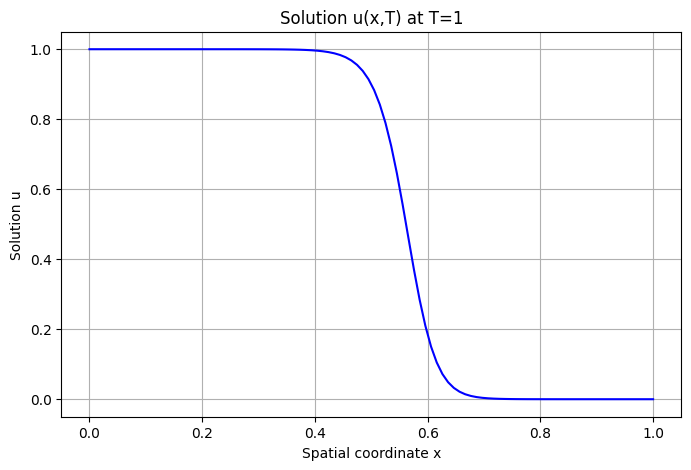

Total number of Newton iterations over all time steps: 302


In [36]:
# Parameters
m = 100
dt = 0.01
T = 1.0
nTimeSteps = int(T/dt)  # 100 steps
nu = 0.01
ua = 1.0
ub = 0.0

sols, x, total_newton_iterations = burgersModel(dt, nTimeSteps, m, nu, ua, ub)

# Plot the solution at final time T=1
final_solution = sols[-1]

plt.figure(figsize=(8,5))
plt.plot(x, final_solution, '-b')
plt.xlabel('Spatial coordinate x')
plt.ylabel('Solution u')
plt.title('Solution u(x,T) at T=1')
plt.grid(True)
plt.show()

print(f"Total number of Newton iterations over all time steps: {total_newton_iterations}")


---

## Parts (1)(d)(e) Analysis and Implementation

---


### Part (1)(d) Upwind:

#### Parameters:  
- $\nu = 0.01$, $\Delta t = 0.01$, $h = 0.01$, and $m = 100$.

#### Output:  
- Total Newton iterations: $302$  
- Wavefront speed $c_{\text{num}} \approx 0.4593$  

#### Analysis:
- This result suggests that the numerical wavefront travels to the right at about **0.4593** units per second over the time interval from $t = 0$ to $t = 1$. The solver converged at each time step, and the number of Newton iterations (**302** total over all 100 time steps) seems reasonable (an average of about 3 iterations per time step). 



---

In [37]:
def myNewtonSys(fnon, jac, x0, tol, maxk, *fnonargs):
    k = 0
    x = x0.copy()
    F = eval(fnon)(x,*fnonargs)
    n = F.size

    while (norm(F,2) > tol and k < maxk):
        J = eval(jac)(x,n,fnon,F,*fnonargs)
        delta = np.linalg.solve(J,-F)
        x = x + delta
        F = eval(fnon)(x,*fnonargs)
        k += 1

    if (k >= maxk):
        print('Warning: Newton not converged within max iterations')
    return x, k

def fdJacobian(x,n,fnon,F0,*fnonargs):
    J = np.zeros((n,n), dtype=np.float64)
    h = 1e-8
    for col in range(n):
        xb = x.copy()
        xb[col] += h
        F = eval(fnon)(xb,*fnonargs)
        for i in range(n):
            J[i,col] = (F[i] - F0[i]) / h
    return J


In [38]:
def fun_burgers(uk, ukp, dt, h, nu, ua, ub, scheme='upwind'):
    m = uk.size
    F = np.zeros(m)

    # Boundary conditions
    F[0] = uk[0] - ua
    F[m-1] = uk[m-1] - ub

    # Internal nodes
    for i in range(1, m-1):
        term_time = (uk[i] - ukp[i]) / dt

        if scheme == 'upwind':
            # upwind: U_i^k * ((U_i^k - U_{i-1}^k)/h)
            term_conv = uk[i] * ((uk[i] - uk[i-1]) / h)
        elif scheme == 'downwind':
            # downwind: U_i^k * ((U_{i+1}^k - U_i^k)/h)
            term_conv = uk[i] * ((uk[i+1] - uk[i]) / h)
        else:
            raise ValueError("Unknown scheme: {}".format(scheme))

        term_diff = nu * (uk[i+1] - 2*uk[i] + uk[i-1]) / (h**2)
        F[i] = term_time + term_conv - term_diff

    return F

def initialData_step(m):
    # Step at x=0.1
    x = np.linspace(0,1,m)
    u0 = np.zeros(m)
    u0[x <= 0.1] = 1.0
    return u0

def wavefront_position(u):
    # p(t) = (1/m)*sum u_i
    return np.mean(u)


In [39]:
def burgersModel(dt, nTimeSteps, m, nu, ua, ub, scheme='upwind'):
    h = 1.0/(m-1)
    uOld = initialData_step(m)
    sols = [uOld.copy()]

    total_newton_iterations = 0

    for k in range(nTimeSteps):
        # Solve nonlinear system using Newton
        u, newton_iters = myNewtonSys("fun_burgers", "fdJacobian", uOld.copy(), 1e-8, 50, uOld, dt, h, nu, ua, ub, scheme)
        uOld = u.copy()
        sols.append(uOld.copy())
        total_newton_iterations += newton_iters

    x = np.linspace(0,1,m)
    return sols, x, total_newton_iterations


Part (d): Using upwind scheme
Total Newton iterations: 302
Wavefront speed c_num: 0.4593330058057634


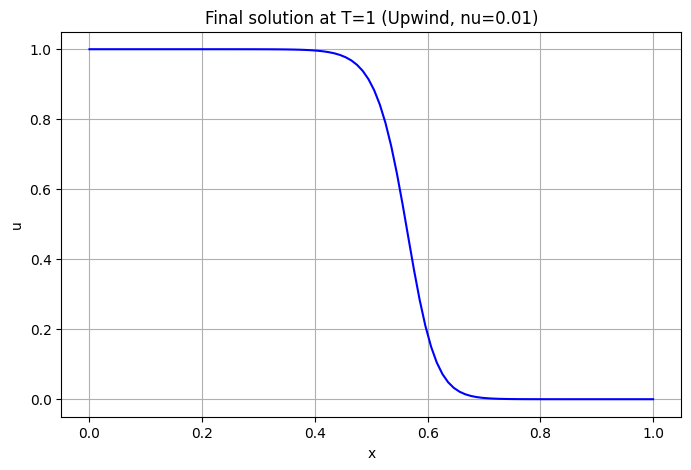

In [40]:
# Parameters for part (d)
m = 100
dt = 0.01
T = 1.0
nTimeSteps = int(T/dt)
nu = 0.01
ua = 1.0
ub = 0.0

# Solve with upwind (original scheme)
sols_upwind, x, total_newton_iter_upwind = burgersModel(dt, nTimeSteps, m, nu, ua, ub, scheme='upwind')

# Compute wave-speed
p0 = wavefront_position(sols_upwind[0])      # p(0)
pT = wavefront_position(sols_upwind[-1])     # p(1)
c_num_upwind = (pT - p0)/T

print("Part (d): Using upwind scheme")
print("Total Newton iterations:", total_newton_iter_upwind)
print("Wavefront speed c_num:", c_num_upwind)

# Plot final solution at T=1
plt.figure(figsize=(8,5))
plt.plot(x, sols_upwind[-1], '-b')
plt.title("Final solution at T=1 (Upwind, nu=0.01)")
plt.xlabel("x")
plt.ylabel("u")
plt.grid(True)
plt.show()


---
### Part (1)(e) Downwind:
#### i) Downwind with $\nu = 0.01$ :

##### Parameters:
- Using the downwind difference formula with the same parameters ($\nu = 0.01$, $\Delta t = 0.01$, $m = 100$, $Scheme=downwind$):  
##### Output:
- Total Newton iterations: $302$ (same as upwind)  
- Wavefront speed $c_{\text{num}} \approx 0.5492$  

##### Analysis:
- The downwind scheme converged cleanly, required a similar total number of Newton iterations, but yielded a faster wavefront speed ($\approx 0.5492$) compared to the upwind scheme. This indicates that the choice of directional differencing for the convection term affects the predicted wave-speed.

---

#### ii) Downwind with $\nu = 0.001$:

##### Parameters:
- With lower viscosity ($\nu = 0.001$, $\Delta t = 0.01$, $m = 100$, $Scheme=downwind$), the code produced multiple warnings: "Newton not converged within max iterations." This suggests difficulty in resolving the nonlinear system at each time step due to reduced diffusivity.  

##### Output:
After many warnings, it still reports a final result:  
- Total Newton iterations: $2334$ (very high compared to $\nu = 0.01$)  
- Wavefront speed $c_{\text{num}} \approx -0.0954$  

##### Analysis:
- A negative wave-speed indicates something unphysical: the wavefront appears to move to the left rather than to the right, which is contrary to the expected physics of this problem. The large number of Newton warnings strongly suggests the solution is not stable or reliable. This scenario indicates that the downwind discretization is not suitable for lower viscosity conditions. Thus, for $ν=0.001$ and downwind differencing, the solution does not converge in a physically meaningful manner.

---

#### iii) Upwind with $\nu = 0.001$:

##### Parameters:
- Switching back to the upwind scheme as ($\nu = 0.001$, $\Delta t = 0.01$, $m = 100$, $Scheme=upwind$):

##### Output:
- Total Newton iterations: $403$  
- Wavefront speed $c_{\text{num}} \approx 0.3723$  

##### Analysis:
- Here, even at lower viscosity, the upwind scheme manages to converge without a flood of warnings, although it does take slightly more iterations than at $\nu = 0.01$. The resulting wave-speed $(0.3723)$ is positive and plausible, indicating a stable solution.

Part (e): Downwind difference formula, nu=0.01
nu=0.01:
Total Newton iterations (downwind): 302
Wavefront speed c_num (downwind): 0.5492130768210111


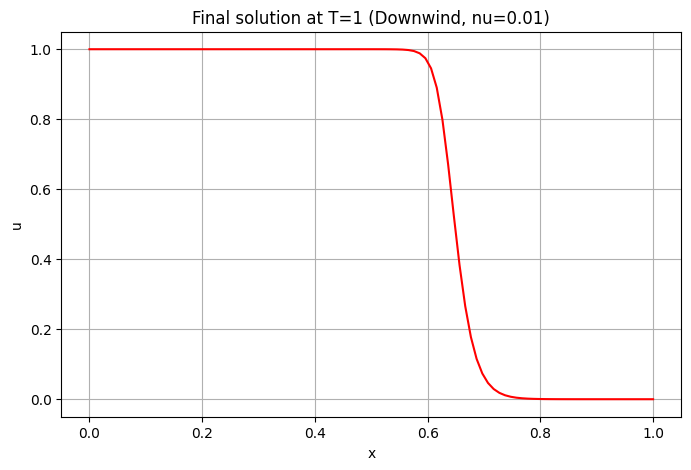


Now nu=0.001 with downwind scheme
Downwind with nu=0.001 converged.
Total Newton iterations: 2334
Wavefront speed c_num: -0.09543372004072971


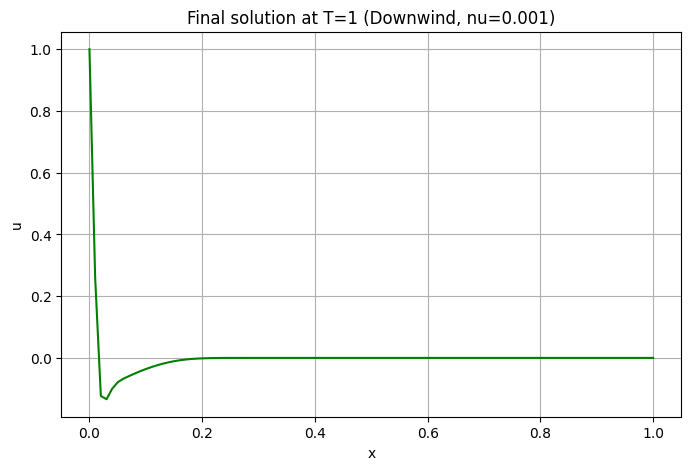


Upwind scheme with nu=0.001
Total Newton iterations (upwind, nu=0.001): 403
Wavefront speed c_num (upwind, nu=0.001): 0.3723179656165143


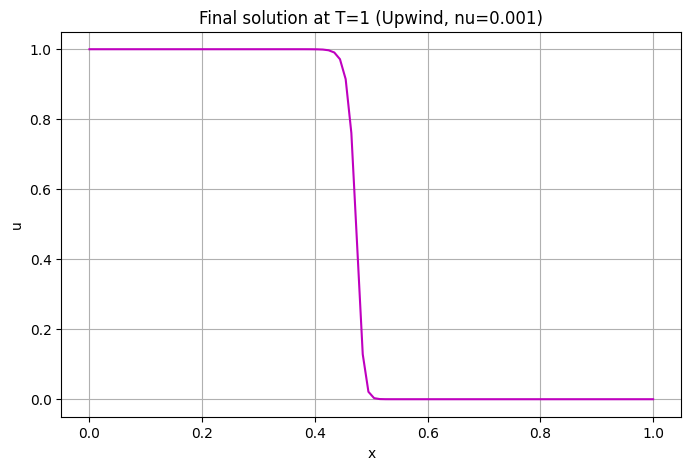

In [41]:
# Part (e) with downwind difference formula
print("Part (e): Downwind difference formula, nu=0.01")

sols_downwind_001, x, total_newton_iter_downwind_001 = burgersModel(dt, nTimeSteps, m, 0.01, ua, ub, scheme='downwind')
p0_dw = wavefront_position(sols_downwind_001[0])
pT_dw = wavefront_position(sols_downwind_001[-1])
c_num_downwind_001 = (pT_dw - p0_dw)/T

print("nu=0.01:")
print("Total Newton iterations (downwind):", total_newton_iter_downwind_001)
print("Wavefront speed c_num (downwind):", c_num_downwind_001)

plt.figure(figsize=(8,5))
plt.plot(x, sols_downwind_001[-1], '-r')
plt.title("Final solution at T=1 (Downwind, nu=0.01)")
plt.xlabel("x")
plt.ylabel("u")
plt.grid(True)
plt.show()


# Now try nu=0.001 with downwind
print("\nNow nu=0.001 with downwind scheme")
try:
    sols_downwind_0001, x, total_newton_iter_downwind_0001 = burgersModel(dt, nTimeSteps, m, 0.001, ua, ub, scheme='downwind')
    p0_dw_0001 = wavefront_position(sols_downwind_0001[0])
    pT_dw_0001 = wavefront_position(sols_downwind_0001[-1])
    c_num_downwind_0001 = (pT_dw_0001 - p0_dw_0001)/T
    print("Downwind with nu=0.001 converged.")
    print("Total Newton iterations:", total_newton_iter_downwind_0001)
    print("Wavefront speed c_num:", c_num_downwind_0001)

    plt.figure(figsize=(8,5))
    plt.plot(x, sols_downwind_0001[-1], '-g')
    plt.title("Final solution at T=1 (Downwind, nu=0.001)")
    plt.xlabel("x")
    plt.ylabel("u")
    plt.grid(True)
    plt.show()

except Exception as e:
    print("Downwind with nu=0.001 did not converge or was not stable. Error:", e)

# Finally, solve with upwind and nu=0.001 for comparison
print("\nUpwind scheme with nu=0.001")
sols_upwind_0001, x, total_newton_iter_upwind_0001 = burgersModel(dt, nTimeSteps, m, 0.001, ua, ub, scheme='upwind')
p0_upw_0001 = wavefront_position(sols_upwind_0001[0])
pT_upw_0001 = wavefront_position(sols_upwind_0001[-1])
c_num_upwind_0001 = (pT_upw_0001 - p0_upw_0001)/T

print("Total Newton iterations (upwind, nu=0.001):", total_newton_iter_upwind_0001)
print("Wavefront speed c_num (upwind, nu=0.001):", c_num_upwind_0001)

plt.figure(figsize=(8,5))
plt.plot(x, sols_upwind_0001[-1], '-m')
plt.title("Final solution at T=1 (Upwind, nu=0.001)")
plt.xlabel("x")
plt.ylabel("u")
plt.grid(True)
plt.show()


---

### Overall:

- For $\nu = 0.01$, both upwind and downwind schemes give stable solutions but different wave-speeds, with downwind predicting a faster wavefront.  
- For $\nu = 0.001$, the downwind scheme fails to produce a stable solution (negative wave-speed), while the upwind scheme still converges and provides a realistic (positive) wave-speed.

---